In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from helpers.simulation import *
from helpers.qtransform import *

from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
from helpers.simulation import *
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']
    
pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
         'keep_noises': ['test-mass', 'oms']}

z = 5
dL = Planck18.luminosity_distance(z).value
m1, m2 = 1e6, 1e6

gws = [{'type': 'BinaryInspiralGW', 'm1': 5e6, 'm2': 5e6,
         'd': dL, 'iota':0, 'spin1': 0, 'spin2': 0, 't_inj': 5*3600,
        'gw_beta':0, 'gw_lambda':0}]

glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': 4*3600,
              'beta': 20, 'level':2*5e-13*20,
                'inj_point':'tm_12'}]

run_simulation(
            gws, glitches, pipe,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=pipe['keep_noises']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [175]:
from helpers.qtransform import *

def run_one_sample(tdi_dict, qparams):
    trange, frange, Q = qparams
    event = {'t_inj':5*3600}
    res = 256

    t_arr, f_arr, QT = generate_qscan(tdi_dict, 'A', PIPE, event, resolution=res,
                                frange=frange, trange=trange, Q=Q)

    score = np.percentile(QT, 99)  
    return score

In [ ]:
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

trange = (-3, 3)
frange = (1e-4, 1e-1)

scores = []
Qvals = np.array([4, 8, 16, 32])
for Q in Qvals:
    qparams = (trange, frange, Q)
    scores.append(run_one_sample(tdi_dict, qparams))

scores = np.array(scores)

In [3]:
#Q = Qvals[scores == np.max(scores)][0]
#print(scores)
#print(Q)

tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)
event = 5*3600
res = 256

t_arr, f_arr, QT = generate_qscan(tdi_dict, 'A', pipe, event, resolution=res,
                            frange=(1e-4, 1e-1), trange=(-3, 3), Q=6)

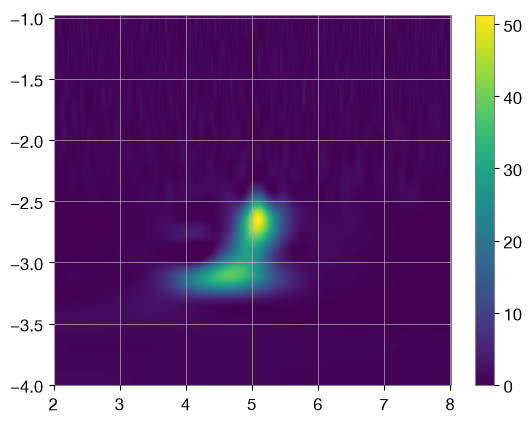

In [4]:
plt.imshow(QT, extent=[t_arr[0]/3600, t_arr[-1]/3600, np.log10(f_arr[0]), np.log10(f_arr[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 60)
plt.show()

In [15]:
gw = BinaryInspiralGW(m1=1e5, m2=1e5, d=1e5, t_inj=15*3600,\
                       spin1=0, spin2=0, iota=0, t0 = 0,\
                        gw_beta=0, gw_lambda=0, orbits=orbits_path)

You are using an orbit file in a version that might not be fully supported


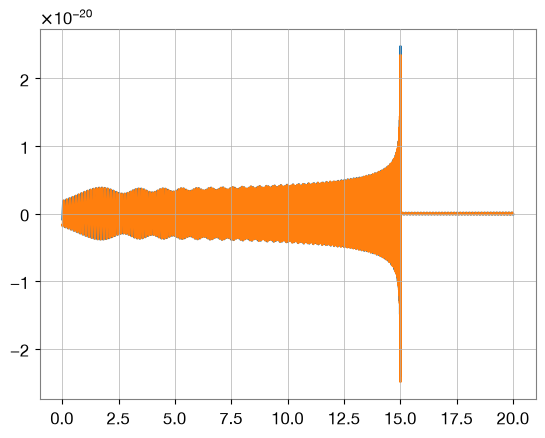

In [16]:
t = np.arange(0, 20*3600, 0.25)
hp = gw.compute_hplus(t)
hc = gw.compute_hcross(t)

plt.plot(t/3600, hp)
plt.plot(t/3600, hc)
#plt.xlim(4.8, 5.2)
plt.show()

## Sampling

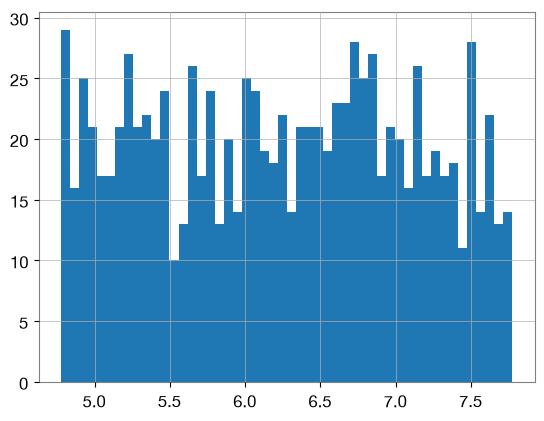

In [184]:
z_arr = np.random.uniform(0.5, 9, size=1000)
d_arr = Planck18.luminosity_distance(z_arr).value

Mc_array = 10**np.random.uniform(4, 7, size=1000)
q_array = np.random.uniform(1, 5, size=1000)

m1_arr = Mc_array * ((1 + q_array)**(1/5) / q_array**(3/5)) * (1+z)
m2_arr = m1_arr * q_array

chirp = chirp_mass(m1_arr, m2_arr)

plt.hist(np.log10(chirp), bins=50)
plt.show()

In [ ]:
gw_dict = {}

with h5py.File(gw_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        gw_dict[key] = h5[key][:]

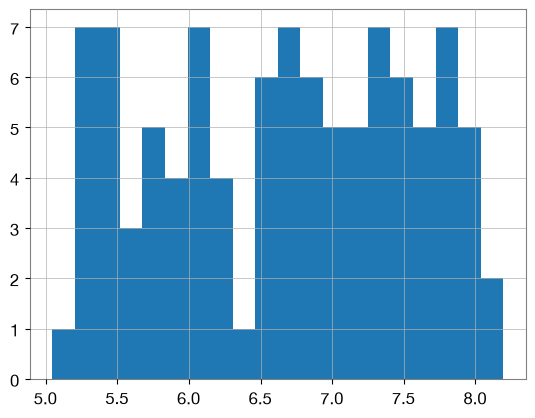

In [292]:
plt.hist(np.log10(gw_dict['m1']+gw_dict['m2']), bins=20)
plt.show()

In [280]:
snrs = []
t = np.arange(0, 10*3600, 0.25)/3600
for i in range(gw_dict['X'].shape[0]):
    tdi_dict = make_tdi_dict(gw_dict['X'][i],
                            gw_dict['Y'][i], gw_dict['Z'][i])
    maximum = np.max(np.abs(tdi_dict['A']))
    noise = np.mean(np.abs(tdi_dict['A'][t < 3]))
    snrs.append(maximum/noise)

snrs = np.array(snrs)

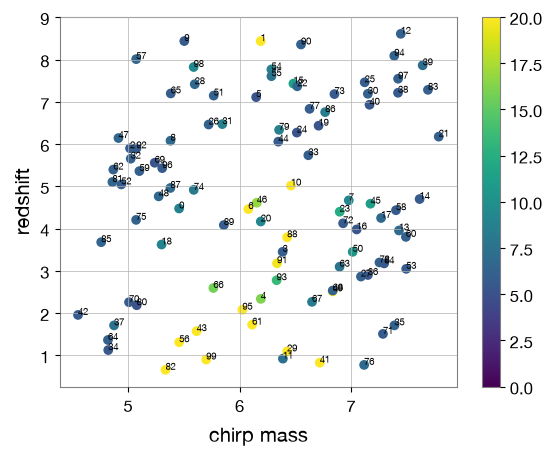

In [286]:
z = z_at_value(Planck18.luminosity_distance, gw_dict['d']*u.Mpc)
chirp = chirp_mass(gw_dict['m1'], gw_dict['m2'])

for i, (xi, yi) in enumerate(zip(np.log10(chirp), z)):
    plt.text(xi, yi, str(i), fontsize=7)

plt.scatter(np.log10(chirp), z, c=snrs)
plt.xlabel('chirp mass')
plt.ylabel('redshift')
plt.clim(0, 20)
plt.colorbar()
plt.show()

7.6585417 8.043546 6.175247669219971 redshift


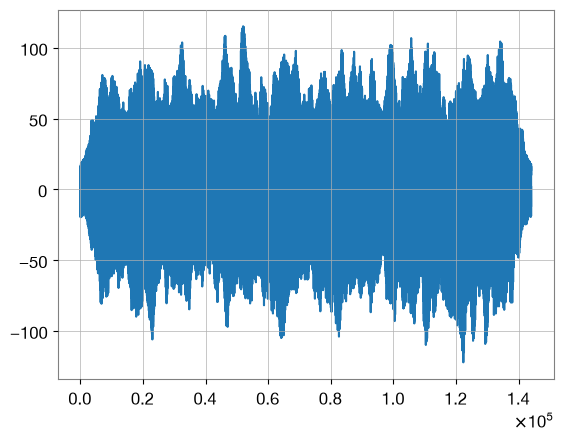

In [290]:
i = 21
tdi_dict = make_tdi_dict(gw_dict['X'][i],
                            gw_dict['Y'][i], gw_dict['Z'][i])

print(np.log10(gw_dict['m1'][i]), np.log10(gw_dict['m2'][i]), z[i])
plt.plot(tdi_dict['A'])
plt.show()

## Really high mass tester

In [6]:
from lisagwresponse import ResponseFromStrain
from pycbc.waveform import get_fd_waveform, get_td_waveform
from scipy.interpolate import interp1d

C = 3e8
G = 6.67e-11

class BinaryInspiralGW(ResponseFromStrain):
    """Represents a GW resulting from a binary merger.
    """
    def __init__(self, m1, m2, d, t_inj, spin1=0.0, spin2=0.0, iota=0.0, tcoeff=1.5, t0=0,
                **kwargs,) -> None:
        super().__init__(**kwargs)
        self.t_inj = float(t_inj)
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.d = float(d)
        self.spin1 = float(spin1)
        self.spin2 = float(spin2)
        self.iota = float(iota)
        self.dur = self.t_inj - t0

        rmin = (36*G*(self.m1 + self.m2)*2e30)/(C**2)
        self.ri = np.maximum(self.compute_ri(self.m1, self.m2, self.dur), rmin)
        self.f_lower = self.compute_flower(self.m1, self.m2, self.ri)
        
        total_time = np.maximum(self.compute_tcoal(self.m1, self.m2, rmin), 1.5*self.dur)
        self.delta_f = self.f_lower/1e3

        hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                    mass1=self.m1, mass2=self.m2, delta_f=self.delta_f,
                    f_lower=self.f_lower, distance=self.d, inclination=self.iota,
                    spin1z = self.spin1, spin2z = self.spin2)
        self.hp = hp_fd.to_timeseries()
        self.hc = hc_fd.to_timeseries()

        self.habs = np.array(np.sqrt(self.hp**2+self.hc**2))

    def compute_tcoal(self, m1, m2, r):
        m1 = m1*2e30
        m2 = m2*2e30
        m = (m1 + m2)
        mu = m1*m2/(m1+m2)
        return (5/256)*((C**5)*(r**4))/((G**3)*(m**2)*mu)

    def compute_ri(self, m1, m2, ti):
        m1 = m1*2e30
        m2 = m2*2e30
        m = (m1 + m2)
        mu = m1*m2/(m1+m2)
        return (((G**3)*(m**2)*mu*ti)/((C**5))*(256/5))**(1/4)
    
    def compute_flower(self, m1, m2, r) -> float:
        Mt = (m1 + m2)*2e30
        return (1/np.pi)*(np.sqrt(G*Mt)/(r**1.5))

    def compute_hplus(self, t) -> np.ndarray:
        return self.compute_signal(self.hp, t)

    def compute_hcross(self, t) -> np.ndarray:
        return self.compute_signal(self.hc, t)

    def compute_signal(self, h, t):
        h.start_time = 0
        i_peak = np.argmax(self.habs)
        peak_time = h.sample_times[i_peak]
        delta_t = self.t_inj - t[0]
        h = h.cyclic_time_shift(-(peak_time - delta_t))
        h.start_time = 0
        
        mask1 = h.sample_times < delta_t + 20000
        sigslice = h[mask1]
        tslice = h.sample_times[mask1]
        tslice = tslice + t[0]
        f = interp1d(tslice, sigslice, kind='cubic',
                         bounds_error=False, fill_value=0)
        
        return f(t)

In [54]:
class BinaryInspiralGW2(ResponseFromStrain):
    """Represents a GW resulting from a binary merger.
    """
    def __init__(self, m1, m2, d, t_inj, spin1=0.0, spin2=0.0, iota=0.0,
                 domain='freq', **kwargs,) -> None:
        super().__init__(**kwargs)
        self.t_inj = float(t_inj)
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.d = float(d)
        self.spin1 = float(spin1)
        self.spin2 = float(spin2)
        self.iota = float(iota)
        self.domain = domain
        self.f_lower = self.compute_flower()

        if self.domain == 'time':
            hp_td, hc_td = get_td_waveform(approximant="IMRPhenomXHM",
                mass1=self.m1, mass2=self.m2, delta_t=1e-3/self.f_lower, f_lower=self.f_lower, 
                inclination=self.iota, distance=self.d, spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_td
            self.hc = hc_td
            
        elif self.domain == 'freq':
            hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                        mass1=self.m1, mass2=self.m2, delta_f=self.f_lower/1e3,
                        f_lower=self.f_lower, distance=self.d, inclination=self.iota,
                        spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_fd.to_timeseries()
            self.hc = hc_fd.to_timeseries()
        
        self.habs = np.array(np.sqrt(self.hp**2+self.hc**2))

    def compute_flower(self) -> float:
        c = 3e8
        G = 6.67e-11
        M = (self.m1 + self.m2)*2e30
        r = 6
        return (c**3)/(((6*r)**1.5)*np.pi*G*M)

    def compute_hplus(self, t) -> np.ndarray:
        return self.compute_signal(self.hp, t)

    def compute_hcross(self, t) -> np.ndarray:
        return self.compute_signal(self.hc, t)

    def compute_signal(self, h, t):
        h.start_time = 0
        i_peak = np.argmax(self.habs)
        peak_time = h.sample_times[i_peak]
        delta_t = self.t_inj - t[0]
        h = h.cyclic_time_shift(-(peak_time - delta_t))
        h.start_time = 0
        
        mask1 = h.sample_times < delta_t + 20000
        sigslice = h[mask1]
        tslice = h.sample_times[mask1]
        tslice = tslice + t[0]
        f = interp1d(tslice, sigslice, kind='cubic',
                         bounds_error=False, fill_value=0)
        return f(t)

In [9]:
#from helpers.gw_shapes import *

gw = BinaryInspiralGW(m1=1e6, m2=1e6, d=1e5, iota=0, spin1=0, spin2=0, t_inj=5*3600,
                    gw_beta=0, gw_lambda=0, orbits=orbits_path)

You are using an orbit file in a version that might not be fully supported


In [12]:
gw.ri*((C**2)/(6*G*(gw.m1 + gw.m2)*2e30))

4.355332860133698

In [67]:
gw.delta_f, gw.f_lower # For GW 1

(np.float64(1.491331925523757e-08), np.float64(1.491331925523757e-05))

In [49]:
gw.f_lower/1e3, gw.f_lower # For GW 2

(1.4913319255237567e-07, 0.00014913319255237568)

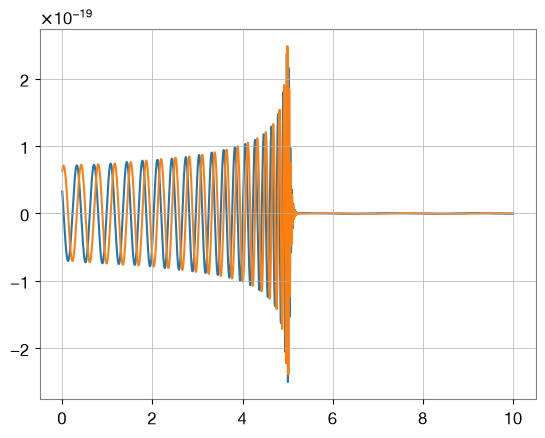

In [11]:
t = np.arange(0, 10*3600, 0.25)
hc = gw.compute_hcross(t)
hp = gw.compute_hplus(t)

#f = 1.3e-4
#Y = np.max(y)*np.cos(2*np.pi*f*(t-5*3600))

plt.plot(t/3600, hp)
plt.plot(t/3600, hc)
#plt.xlim(340, 360)
plt.show()

In [66]:
def compute_flower(m1, m2) -> float:
        c = 3e8
        G = 6.67e-11
        M = (m1 + m2)*2e30
        r = 6
        return (c**3)/(((6*r)**1.5)*np.pi*G*M)

In [67]:
m1, m2 = 1e7, 1e7
f_lower = compute_flower(m1, m2)
f_lower/1e-4

0.1491331925523757

In [68]:
hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                        mass1=m1, mass2=m2, delta_f=f_lower/1e3,
                        f_lower=f_lower, distance=1e5, inclination=0,
                        spin1z = 0, spin2z = 0)
hp = hp_fd.to_timeseries()
hc = hc_fd.to_timeseries()

In [69]:
delta_t = hp.delta_t
print(delta_t)

127.89564818996531


In [47]:
1 / (2 * (len(hp_fd) - 1) * hp_fd.delta_f)

12.789564818996535

In [79]:
hp_td, hc_td = get_td_waveform(approximant="IMRPhenomXHM",
                        mass1=m1, mass2=m2, delta_t=0.0025,
                        f_lower=1e-4, distance=1e5, inclination=0,
                        spin1z = 0, spin2z = 0)

ValueError: Parameter Nx=0 is not a positive integer

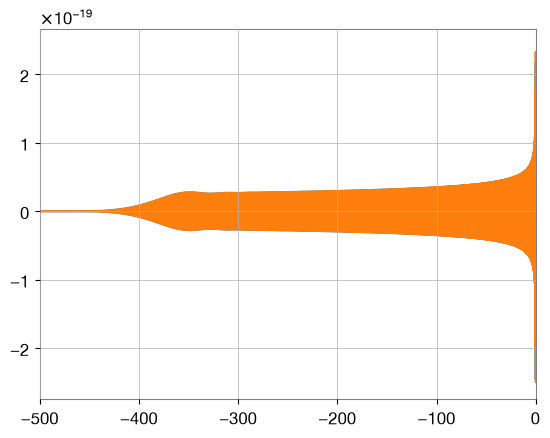

In [51]:
plt.plot(hp_td.sample_times/3600, hp_td)
plt.plot(hc_td.sample_times/3600, hc_td)
plt.xlim(-500, 0)
plt.show()